Starting experiments (SAC continuous mechanism, fixed)...

Belief Update Mode: pure_bayes

Training MDP with pure_bayes...
  Learned mechanism (deterministic policy at reset state):
[[2.6175825e-04 9.9973828e-01 4.3496748e-09]
 [3.8358226e-02 3.4912064e-04 9.6129268e-01]
 [6.4748957e-09 2.3079862e-09 1.0000000e+00]]
  Final cost: 232.70
  Training time: 54.5s

Training POMDP with pure_bayes...
  Learned mechanism (deterministic policy at reset state):
[[9.2524755e-16 2.4870201e-11 1.0000000e+00]
 [8.3422411e-04 4.1640061e-03 9.9500173e-01]
 [9.9177903e-01 8.1638945e-03 5.7067249e-05]]
  Final cost: 214.58
  Training time: 235.4s

Training Two-Stage with pure_bayes...
  Learned mechanism (deterministic policy at reset state):
[[4.4545615e-08 1.0000000e+00 2.1302218e-14]
 [3.2108399e-01 4.9761963e-01 1.8129641e-01]
 [7.8608218e-06 9.0949993e-16 9.9999213e-01]]
  Final cost: 210.26
  Training time: 78.7s

Belief Update Mode: anchored_bayes

Training MDP with anchored_bayes...
  Learned me

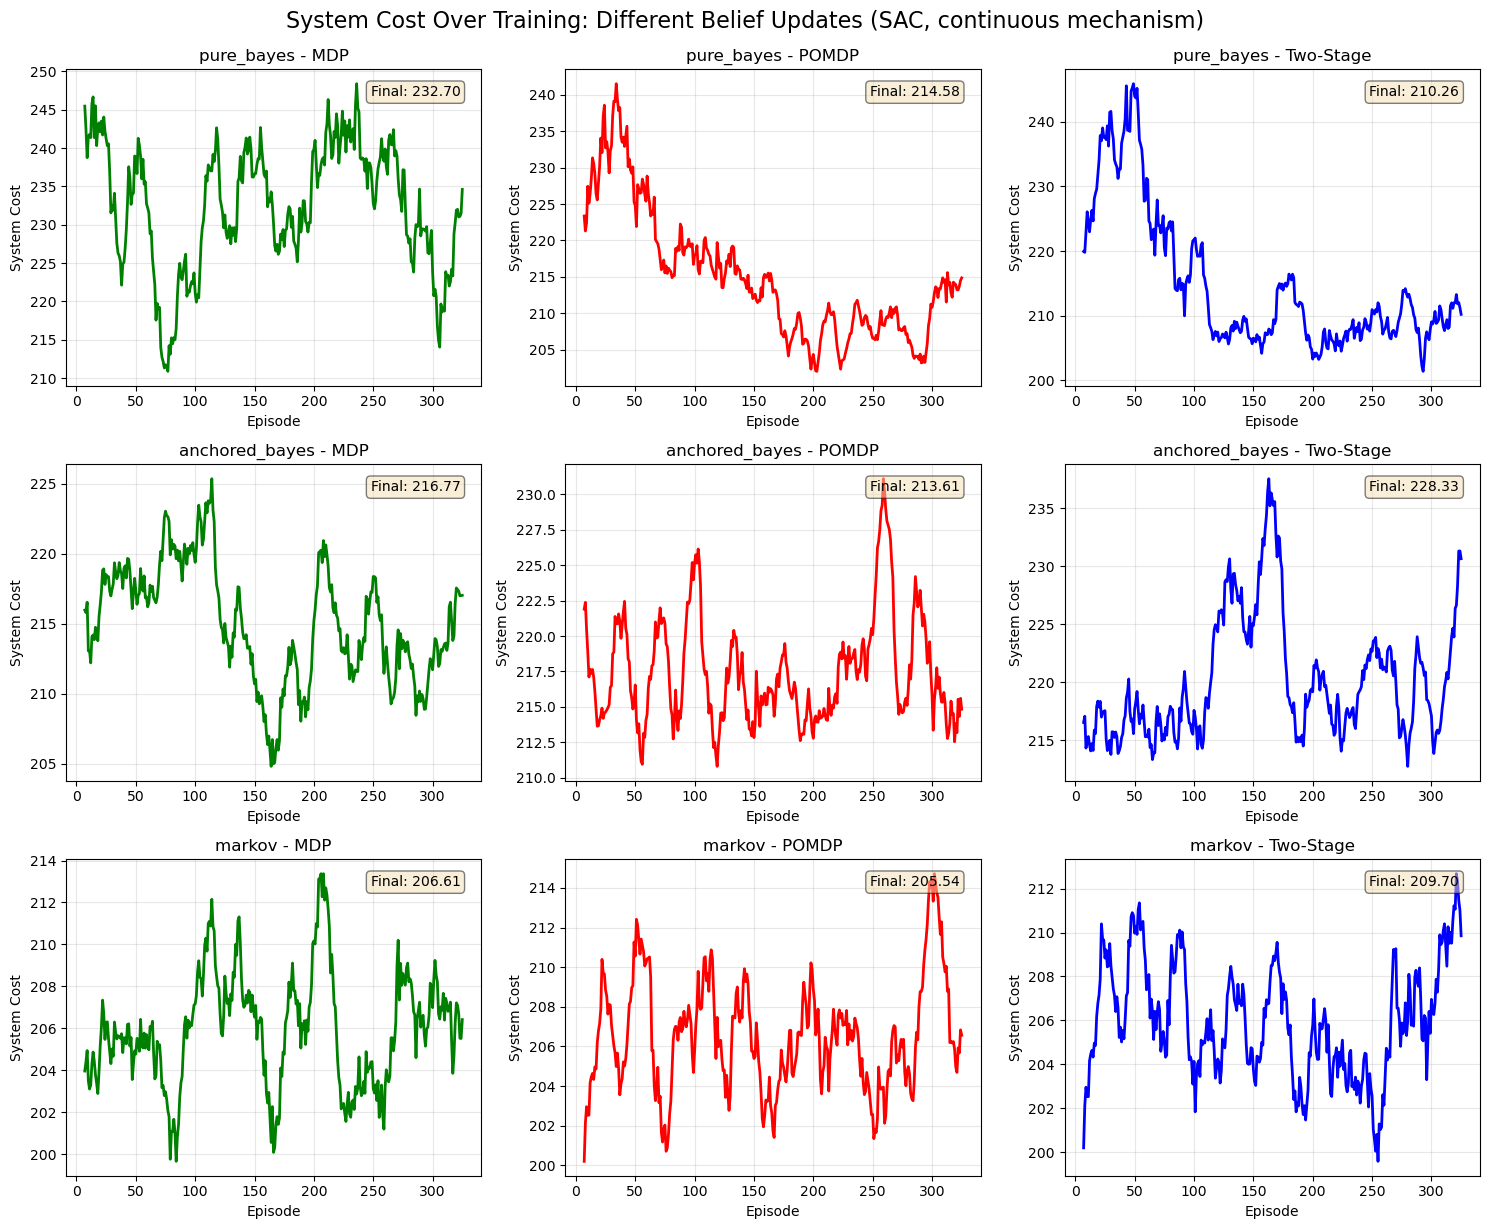

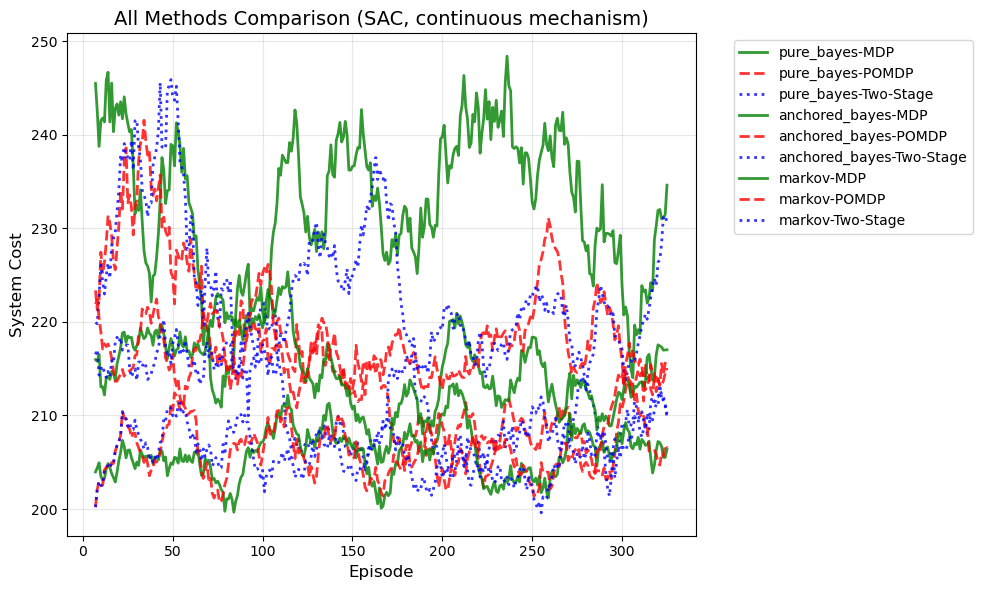


SUMMARY

Belief Mode     Method     Final Cost   Time (s)
----------------------------------------------------------------------
pure_bayes      MDP        232.70       54.5
pure_bayes      POMDP      214.58       235.4
pure_bayes      Two-Stage  210.26       78.7
anchored_bayes  MDP        216.77       54.3
anchored_bayes  POMDP      213.61       238.5
anchored_bayes  Two-Stage  228.33       98.4
markov          MDP        206.61       54.5
markov          POMDP      205.54       237.5
markov          Two-Stage  209.70       80.7


In [5]:
"""
=============================================================================
Sioux Falls 拥堵信号实验 - 信念更新方式对比 (SAC 连续机制版, 修正版)
=============================================================================

- 3种信念更新方式: Pure Bayes, Anchored Bayes, Markov
- 3种方法: MDP, POMDP, Two-Stage
- 统一用 SAC 学一个连续的 signaling mechanism:
    action a ∈ R^{n_states * n_states}
    -> reshape 成 (n_states, n_states) logits
    -> softmax 行归一化 -> 机制矩阵 η
    -> 在真实状态 s 下，从 η[s, :] 中 sample 离散信号 k
    -> TravelerBelief 根据 (η, k) 进行贝叶斯更新
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Dict, Tuple, List, Optional
import time
from dataclasses import dataclass, field
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# ===========================================================
# 0. Config
# ===========================================================

@dataclass
class Config:
    # 信念更新参数
    belief_update_mode: str = "pure_bayes"  # "pure_bayes", "anchored_bayes", "markov"
    anchor_weight: float = 0.1  # 用于anchored_bayes模式
    
    # 网络配置
    major_od_pairs: List[Tuple[int, int, float]] = field(default_factory=lambda: [
        (1, 20, 35000)
    ])
    k_paths_per_od: int = 3
    bpr_alpha: float = 0.15
    bpr_beta: float = 4.0
    
    # 路径设计
    fixed_paths: Dict[Tuple[int, int], List[List[int]]] = field(default_factory=lambda: {
        (1, 20): [
            [1, 2, 6, 8, 16, 18, 20],        # 路径1: 高速型-北线
            [1, 3, 4, 5, 9, 10, 17, 19, 20], # 路径2: 稳定型-南线
            [1, 3, 12, 13, 24, 21, 20],      # 路径3: 混合型-中线
        ]
    })
    
    # 主干道定义
    major_roads: List[Tuple[int, int]] = field(default_factory=lambda: [
        (1, 2), (2, 6), (6, 8), (8, 16), (16, 18), (18, 20),
        (12, 13), (24, 21), (21, 20),
    ])
    
    # 拥堵影响
    congestion_multipliers: Dict[str, Dict[int, float]] = field(default_factory=lambda: {
        'major': {0: 0.8, 1: 2.5, 2: 6.0},
        'minor': {0: 1.5, 1: 1.8, 2: 2.0}
    })
    
    # SUE参数
    sensitivity: float = 0.6
    sue_max_iters: int = 15
    
    # 噪声
    latency_noise_std: float = 1.0
    filter_noise_std: float = 1.5
    
    # 状态空间
    n_states: int = 3
    state_persistence: float = 0.5
    
    # 滤波器
    n_particles: int = 10
    resample_threshold: float = 0.5
    
    # Episode结构
    commit_len: int = 10
    n_commits_per_episode: int = 15
    
    # Two-Stage参数
    use_adaptive_switch: bool = True
    variance_threshold: float = 0.001
    min_warmup_commits: int = 2
    max_warmup_commits: int = 8
    
    # SAC / 训练参数
    learning_rate: float = 3e-4
    gamma: float = 0.95
    hidden_dim: int = 128
    alpha: float = 0.2          # 温度参数（固定）
    tau: float = 0.005          # target 网络 soft update
    batch_size: int = 128
    replay_size: int = 100000
    start_steps: int = 500      # 先随机探索
    update_after: int = 500
    update_every: int = 1       # 每步更新一次
    
    max_timesteps: int = 5000
    log_freq: int = 500
    random_seed: int = 42
    
    # Reward设置
    use_differential_reward: bool = True
    reward_clip_min: float = -10.0
    reward_clip_max: float = 10.0
    baseline_calibration_steps: int = 30
    
    initial_belief: Optional[np.ndarray] = None
    
    def __post_init__(self):
        if self.initial_belief is None:
            self.initial_belief = np.array([0.6, 0.3, 0.1])


# ===========================================================
# 1. Sioux Falls Network + SUE
# ===========================================================

class Network:
    def __init__(self, config: Config):
        self.config = config
        self.G = self._create_sioux_falls_graph()
        self.paths = {}
        self.path_list = []
        self.od_to_path_idx = {}
        self._use_fixed_paths()
        self.n_paths = len(self.path_list)
        self.edge_path_matrix = self._build_edge_path_matrix()
        self.major_roads_set = set(self.config.major_roads)
    
    def _create_sioux_falls_graph(self) -> nx.DiGraph:
        G = nx.DiGraph()
        edges = [
            (1, 2, 25900, 6), (1, 3, 23400, 4),
            (2, 1, 25900, 6), (2, 6, 4958, 5),
            (3, 1, 23400, 4), (3, 4, 17110, 4), (3, 12, 23403, 4),
            (4, 3, 17110, 4), (4, 5, 17782, 2), (4, 11, 4908, 6),
            (5, 4, 17782, 2), (5, 6, 4947, 4), (5, 9, 10000, 5),
            (6, 2, 4958, 5), (6, 5, 4947, 4), (6, 8, 4898, 2),
            (7, 8, 7840, 3), (7, 18, 23403, 2),
            (8, 6, 4898, 2), (8, 7, 7840, 3), (8, 9, 5050, 10), (8, 16, 5045, 5),
            (9, 5, 10000, 5), (9, 8, 5050, 10), (9, 10, 13915, 3),
            (10, 9, 13915, 3), (10, 11, 10000, 6), (10, 15, 9599, 7),
            (10, 16, 4824, 4), (10, 17, 5000, 8),
            (11, 4, 4908, 6), (11, 10, 10000, 6), (11, 12, 4823, 3),
            (11, 14, 4909, 4),
            (12, 3, 23403, 4), (12, 11, 4823, 3), (12, 13, 25900, 3),
            (13, 12, 25900, 3), (13, 24, 4909, 4),
            (14, 11, 4909, 4), (14, 15, 5091, 5), (14, 23, 4910, 4),
            (15, 10, 9599, 7), (15, 14, 5091, 5), (15, 19, 14564, 3),
            (15, 22, 9600, 3),
            (16, 8, 5045, 5), (16, 10, 4824, 4), (16, 17, 5229, 2),
            (16, 18, 14564, 3),
            (17, 10, 5000, 8), (17, 16, 5229, 2), (17, 19, 4824, 2),
            (18, 7, 23403, 2), (18, 16, 14564, 3), (18, 20, 23403, 4),
            (19, 15, 14564, 3), (19, 17, 4824, 2), (19, 20, 5002, 4),
            (20, 18, 23403, 4), (20, 19, 5002, 4), (20, 21, 5059, 5),
            (20, 22, 5075, 5),
            (21, 20, 5059, 5), (21, 22, 5229, 2), (21, 24, 4823, 3),
            (22, 15, 9600, 3), (22, 20, 5075, 5), (22, 21, 5229, 2),
            (22, 23, 5002, 4),
            (23, 14, 4910, 4), (23, 22, 5002, 4), (23, 24, 5075, 2),
            (24, 13, 4909, 4), (24, 21, 4823, 3), (24, 23, 5075, 2),
        ]
        for u, v, cap, fft in edges:
            G.add_edge(u, v, capacity=cap, fft=fft,
                       alpha=self.config.bpr_alpha, beta=self.config.bpr_beta)
        return G
    
    def _use_fixed_paths(self):
        for o, d, demand in self.config.major_od_pairs:
            if (o, d) in self.config.fixed_paths:
                paths = self.config.fixed_paths[(o, d)]
            else:
                paths = list(nx.shortest_simple_paths(
                    self.G, o, d, weight='fft'))[:self.config.k_paths_per_od]
            self.paths[(o, d)] = paths
            start_idx = len(self.path_list)
            self.od_to_path_idx[(o, d)] = list(range(start_idx, start_idx + len(paths)))
            self.path_list.extend(paths)
    
    def _build_edge_path_matrix(self) -> Dict[Tuple[int, int], np.ndarray]:
        edge_matrix = {}
        for p_idx, path in enumerate(self.path_list):
            for i in range(len(path) - 1):
                e = (path[i], path[i+1])
                if e not in edge_matrix:
                    edge_matrix[e] = np.zeros(self.n_paths)
                edge_matrix[e][p_idx] = 1.0
        return edge_matrix
    
    def _get_edge_flow_fast(self, u: int, v: int, flows: np.ndarray) -> float:
        e = (u, v)
        if e not in self.edge_path_matrix:
            return 0.0
        return np.dot(self.edge_path_matrix[e], flows)
    
    def get_path_latency(self, path_idx: int, flows: np.ndarray, state: int) -> float:
        path = self.path_list[path_idx]
        latency = 0.0
        for i in range(len(path)-1):
            u, v = path[i], path[i+1]
            if not self.G.has_edge(u, v):
                continue
            edge_data = self.G[u][v]
            edge_flow = self._get_edge_flow_fast(u, v, flows)
            cap = edge_data['capacity']
            fft = edge_data['fft']
            alpha = edge_data['alpha']
            beta = edge_data['beta']
            x = edge_flow / max(cap, 1.0)
            base_lat = fft * (1.0 + alpha * (x ** beta))
            if (u, v) in self.major_roads_set:
                mult = self.config.congestion_multipliers['major'][state]
            else:
                mult = self.config.congestion_multipliers['minor'][state]
            latency += base_lat * mult
        return latency
    
    def get_avg_latency(self, flows: np.ndarray, state: int) -> float:
        total_flow = flows.sum()
        if total_flow < 1.0:
            return 0.0
        total = 0.0
        for p in range(self.n_paths):
            total += flows[p] * self.get_path_latency(p, flows, state)
        return total / total_flow


class SUE:
    def __init__(self, network: Network, config: Config):
        self.net = network
        self.config = config
        self.nu = config.sensitivity
        self.od_demands = {(o, d): dem for o, d, dem in config.major_od_pairs}
    
    def solve(self, belief: np.ndarray, n_iters: int = None) -> np.ndarray:
        if n_iters is None:
            n_iters = self.config.sue_max_iters
        
        n_paths = self.net.n_paths
        flows = np.zeros(n_paths)
        for (o, d), p_idx in self.net.od_to_path_idx.items():
            dem = self.od_demands[(o, d)]
            for idx in p_idx:
                flows[idx] = dem / len(p_idx)
        
        for k in range(n_iters):
            costs = self._compute_expected_costs(flows, belief)
            new_flows = np.zeros(n_paths)
            for (o, d), p_idx in self.net.od_to_path_idx.items():
                dem = self.od_demands[(o, d)]
                od_costs = np.array([costs[i] for i in p_idx])
                logits = -self.nu * (od_costs - od_costs.min())
                exp_logits = np.exp(np.clip(logits, -50, 50))
                probs = exp_logits / exp_logits.sum()
                for idx, p in zip(p_idx, probs):
                    new_flows[idx] = dem * p
            alpha = 1.0 / (k + 2)
            flows = (1 - alpha) * flows + alpha * new_flows
        return flows
    
    def _compute_expected_costs(self, flows: np.ndarray, belief: np.ndarray) -> np.ndarray:
        costs = np.zeros(self.net.n_paths)
        for p in range(self.net.n_paths):
            exp_cost = 0.0
            for s in range(self.config.n_states):
                exp_cost += belief[s] * self.net.get_path_latency(p, flows, s)
            costs[p] = exp_cost
        return costs


# ===========================================================
# 2. Belief & Filter
# ===========================================================

class TravelerBelief:
    def __init__(self, config: Config):
        self.config = config
        self.mu_t = config.initial_belief.copy()
        self.mu_0 = config.initial_belief.copy()
        self.P = self._create_transition_matrix()
        self.mode = config.belief_update_mode
        self.anchor_weight = config.anchor_weight
    
    def _create_transition_matrix(self) -> np.ndarray:
        P = np.zeros((self.config.n_states, self.config.n_states))
        persist = self.config.state_persistence
        for i in range(self.config.n_states):
            P[i, i] = persist
            for j in range(self.config.n_states):
                if i != j:
                    P[i, j] = (1 - persist) / (self.config.n_states - 1)
        return P
    
    def update(self, signal: int, mechanism: np.ndarray) -> np.ndarray:
        posterior = self.mu_t * mechanism[:, signal]
        if posterior.sum() > 1e-10:
            posterior = posterior / posterior.sum()
        else:
            posterior = self.mu_t.copy()
        
        if self.mode == "pure_bayes":
            self.mu_t = posterior.copy()
        elif self.mode == "anchored_bayes":
            self.mu_t = self.anchor_weight * self.mu_t + (1 - self.anchor_weight) * posterior
        elif self.mode == "markov":
            self.mu_t = self.P.T @ posterior
        
        return posterior
    
    def get_belief(self) -> np.ndarray:
        return self.mu_t.copy()
    
    def reset(self):
        self.mu_t = self.config.initial_belief.copy()


class BeliefFilter:
    def __init__(self, network: Network, sue: SUE, config: Config):
        self.net = network
        self.sue = sue
        self.config = config
        self.P = TravelerBelief(config).P
        self.mode = config.belief_update_mode
        self.anchor_weight = config.anchor_weight
        
        self.n_particles = config.n_particles
        self.noise_std = config.filter_noise_std
        
        self.particles_mu0 = self._initialize_particles()
        self.particles_mut = [mu.copy() for mu in self.particles_mu0]
        self.weights = np.ones(self.n_particles) / self.n_particles
    
    def _initialize_particles(self) -> List[np.ndarray]:
        particles = []
        alpha = np.ones(self.config.n_states) * 0.8
        for _ in range(self.n_particles):
            mu = np.random.dirichlet(alpha)
            particles.append(mu)
        return particles
    
    def reset(self):
        self.particles_mut = [mu.copy() for mu in self.particles_mu0]
        self.weights = np.ones(self.n_particles) / self.n_particles
    
    def update(self, signal: int, mechanism: np.ndarray, observed_latency: float) -> Tuple[np.ndarray, float]:
        log_liks = np.zeros(self.n_particles)
        
        for i in range(self.n_particles):
            mu_t = self.particles_mut[i]
            
            posterior = mu_t * mechanism[:, signal]
            if posterior.sum() > 1e-10:
                posterior = posterior / posterior.sum()
            else:
                posterior = mu_t.copy()
            
            flows = self.sue.solve(posterior, n_iters=5)
            pred_latency = 0.0
            for s in range(self.config.n_states):
                pred_latency += posterior[s] * self.net.get_avg_latency(flows, s)
            
            err = observed_latency - pred_latency
            log_liks[i] = -0.5 * (err / self.noise_std) ** 2
            
            if self.mode == "pure_bayes":
                self.particles_mut[i] = posterior.copy()
            elif self.mode == "anchored_bayes":
                self.particles_mut[i] = self.anchor_weight * self.particles_mu0[i] + (1 - self.anchor_weight) * posterior
            elif self.mode == "markov":
                self.particles_mut[i] = self.P.T @ posterior
        
        log_liks = log_liks - log_liks.max()
        unnorm = np.exp(log_liks) * self.weights
        if unnorm.sum() > 1e-10:
            self.weights = unnorm / unnorm.sum()
        else:
            self.weights = np.ones(self.n_particles) / self.n_particles
        
        self._resample_if_needed()
        
        estimated_mu = np.zeros(self.config.n_states)
        for i in range(self.n_particles):
            estimated_mu += self.weights[i] * self.particles_mut[i]
        
        variance = 0.0
        for i in range(self.n_particles):
            diff = self.particles_mut[i] - estimated_mu
            variance += self.weights[i] * np.sum(diff ** 2)
        
        return estimated_mu, variance
    
    def _resample_if_needed(self):
        ess = 1.0 / np.sum(self.weights ** 2)
        if ess < self.config.resample_threshold * self.n_particles:
            idx = np.random.choice(self.n_particles, size=self.n_particles, p=self.weights)
            self.particles_mut = [self.particles_mut[i].copy() for i in idx]
            self.weights = np.ones(self.n_particles) / self.n_particles
    
    def get_estimate(self) -> Tuple[np.ndarray, float]:
        estimated_mu = np.zeros(self.config.n_states)
        for i in range(self.n_particles):
            estimated_mu += self.weights[i] * self.particles_mut[i]
        
        variance = 0.0
        for i in range(self.n_particles):
            diff = self.particles_mut[i] - estimated_mu
            variance += self.weights[i] * np.sum(diff ** 2)
        
        return estimated_mu, variance


# ===========================================================
# 3. SAC 组件（连续动作）
# ===========================================================

class ReplayBuffer:
    def __init__(self, obs_dim: int, act_dim: int, size: int):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.next_obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.acts_buf = np.zeros((size, act_dim), dtype=np.float32)
        self.rews_buf = np.zeros(size, dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.float32)
        self.max_size = size
        self.ptr = 0
        self.size = 0
    
    def store(self, obs, act, rew, next_obs, done):
        self.obs_buf[self.ptr] = obs
        self.acts_buf[self.ptr] = act
        self.rews_buf[self.ptr] = rew
        self.next_obs_buf[self.ptr] = next_obs
        self.done_buf[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)
    
    def sample_batch(self, batch_size=32):
        idxs = np.random.randint(0, self.size, size=batch_size)
        batch = dict(
            obs=torch.as_tensor(self.obs_buf[idxs], dtype=torch.float32),
            obs2=torch.as_tensor(self.next_obs_buf[idxs], dtype=torch.float32),
            acts=torch.as_tensor(self.acts_buf[idxs], dtype=torch.float32),
            rews=torch.as_tensor(self.rews_buf[idxs], dtype=torch.float32),
            done=torch.as_tensor(self.done_buf[idxs], dtype=torch.float32),
        )
        return batch


class Actor(nn.Module):
    """Gaussian policy + Tanh, 输出连续动作 a ∈ [-1,1]^act_dim"""
    def __init__(self, obs_dim, act_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim, act_dim)
        self.log_std_layer = nn.Linear(hidden_dim, act_dim)
        self.LOG_STD_MIN = -20
        self.LOG_STD_MAX = 2
    
    def forward(self, obs):
        h = self.net(obs)
        mu = self.mu_layer(h)
        log_std = self.log_std_layer(h)
        log_std = torch.clamp(log_std, self.LOG_STD_MIN, self.LOG_STD_MAX)
        std = torch.exp(log_std)
        return mu, std
    
    def sample(self, obs):
        mu, std = self(obs)
        normal = torch.distributions.Normal(mu, std)
        x_t = normal.rsample()
        a_t = torch.tanh(x_t)
        log_prob = normal.log_prob(x_t) - torch.log(1 - a_t.pow(2) + 1e-6)
        log_prob = log_prob.sum(-1, keepdim=True)
        return a_t, log_prob
    
    def deterministic(self, obs):
        mu, _ = self(obs)
        a_t = torch.tanh(mu)
        return a_t


class Critic(nn.Module):
    """Q 网络: 输入 (state, action) 输出 Q(s,a)"""
    def __init__(self, obs_dim, act_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, obs, act):
        x = torch.cat([obs, act], dim=-1)
        return self.net(x).squeeze(-1)


class SACAgent:
    def __init__(self, obs_dim: int, act_dim: int, config: Config):
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.gamma = config.gamma
        self.tau = config.tau
        self.alpha = config.alpha
        
        self.actor = Actor(obs_dim, act_dim, config.hidden_dim)
        self.q1 = Critic(obs_dim, act_dim, config.hidden_dim)
        self.q2 = Critic(obs_dim, act_dim, config.hidden_dim)
        self.q1_target = Critic(obs_dim, act_dim, config.hidden_dim)
        self.q2_target = Critic(obs_dim, act_dim, config.hidden_dim)
        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())
        
        self.actor_optim = optim.Adam(self.actor.parameters(), lr=config.learning_rate)
        self.q1_optim = optim.Adam(self.q1.parameters(), lr=config.learning_rate)
        self.q2_optim = optim.Adam(self.q2.parameters(), lr=config.learning_rate)
    
    def select_action(self, obs: np.ndarray, deterministic: bool = False) -> np.ndarray:
        obs_t = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            if deterministic:
                a = self.actor.deterministic(obs_t)
            else:
                a, _ = self.actor.sample(obs_t)
        return a.squeeze(0).cpu().numpy()
    
    def update(self, replay: ReplayBuffer, batch_size: int):
        batch = replay.sample_batch(batch_size)
        obs = batch["obs"]
        obs2 = batch["obs2"]
        acts = batch["acts"]
        rews = batch["rews"].unsqueeze(-1)
        done = batch["done"].unsqueeze(-1)
        
        # 1) 更新 Q 网络
        with torch.no_grad():
            a2, logp_a2 = self.actor.sample(obs2)
            q1_target_next = self.q1_target(obs2, a2).unsqueeze(-1)
            q2_target_next = self.q2_target(obs2, a2).unsqueeze(-1)
            q_target_next = torch.min(q1_target_next, q2_target_next)
            backup = rews + self.gamma * (1 - done) * (q_target_next - self.alpha * logp_a2)
        
        q1_val = self.q1(obs, acts).unsqueeze(-1)
        q2_val = self.q2(obs, acts).unsqueeze(-1)
        q1_loss = ((q1_val - backup) ** 2).mean()
        q2_loss = ((q2_val - backup) ** 2).mean()
        
        self.q1_optim.zero_grad()
        q1_loss.backward()
        self.q1_optim.step()
        
        self.q2_optim.zero_grad()
        q2_loss.backward()
        self.q2_optim.step()
        
        # 2) 更新策略网络
        a_pi, logp_a_pi = self.actor.sample(obs)
        q1_pi = self.q1(obs, a_pi)
        q2_pi = self.q2(obs, a_pi)
        q_pi = torch.min(q1_pi, q2_pi)
        actor_loss = (self.alpha * logp_a_pi.squeeze(-1) - q_pi).mean()
        
        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()
        
        # 3) soft update target Q
        with torch.no_grad():
            for p, p_targ in zip(self.q1.parameters(), self.q1_target.parameters()):
                p_targ.data.mul_(1 - self.tau)
                p_targ.data.add_(self.tau * p.data)
            for p, p_targ in zip(self.q2.parameters(), self.q2_target.parameters()):
                p_targ.data.mul_(1 - self.tau)
                p_targ.data.add_(self.tau * p.data)


# ===========================================================
# 4. Environment：连续机制 (action -> mechanism matrix)
# ===========================================================

class BaseEnv:
    def __init__(self, config: Config):
        self.config = config
        self.net = Network(config)
        self.sue = SUE(self.net, config)
        self.n_states = config.n_states
        # 连续动作维度: 每个状态有一行 logits，对 n_states 个信号
        self.action_dim = self.n_states * self.n_states
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = None
        self.traveler = None
        self.baseline = self._calibrate_baseline()
    
    def _calibrate_baseline(self) -> float:
        """用 Perfect identity mechanism 作为 baseline。"""
        costs = []
        temp_traveler = TravelerBelief(self.config)
        mechanism = np.eye(self.n_states)
        
        for _ in range(self.config.baseline_calibration_steps):
            temp_state = np.random.choice(self.n_states, 
                                          p=self.config.initial_belief)
            signal = np.random.choice(self.n_states, 
                                      p=mechanism[temp_state])
            posterior = temp_traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=5)
            latency = self.net.get_avg_latency(flows, temp_state)
            if self.config.latency_noise_std > 0:
                cost = max(0.1, latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                cost = latency
            costs.append(cost)
        
        return np.mean(costs) if costs else 50.0
    
    def _sample_initial_state(self) -> int:
        return np.random.choice(self.n_states, p=self.config.initial_belief)
    
    def _action_to_mechanism(self, action_vec: np.ndarray) -> np.ndarray:
        """
        SAC 输出 a ∈ [-1,1]^{n*n}，reshape 成 (n,n) logits，
        对每一行做 softmax，得到机制矩阵 η[i,j] = P(signal=j | state=i).

        【修正】引入 scaling_factor 使 softmax 可以生成更尖锐的分布。
        """
        n = self.n_states
        scaling_factor = 20.0
        logits = action_vec.reshape(n, n) * scaling_factor
        logits = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
        return probs


class PureMDPEnv(BaseEnv):
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        frac = self.current_commit_idx / max(self.config.n_commits_per_episode - 1, 1)
        state_onehot = np.zeros(self.n_states)
        state_onehot[self.current_state] = 1.0
        belief = self.traveler.get_belief()
        return np.concatenate([state_onehot, belief, [0.0], [frac]]).astype(np.float32)
    
    def step(self, action_vec: np.ndarray):
        mechanism = self._action_to_mechanism(action_vec)
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                cost = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                cost = true_latency
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost,
                                      self.config.reward_clip_min,
                                      self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.n_states,
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {"system_cost": avg_cost}
        return self._get_state(), avg_reward, done, info


class PurePOMDPEnv(BaseEnv):
    def __init__(self, config: Config):
        super().__init__(config)
        self.belief_filter = BeliefFilter(self.net, self.sue, config)
    
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        self.belief_filter.reset()
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        frac = self.current_commit_idx / max(self.config.n_commits_per_episode - 1, 1)
        est_belief, variance = self.belief_filter.get_estimate()
        return np.concatenate([est_belief, [variance], [frac]]).astype(np.float32)
    
    def step(self, action_vec: np.ndarray):
        mechanism = self._action_to_mechanism(action_vec)
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                observed_latency = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                observed_latency = true_latency
            
            cost = observed_latency
            self.belief_filter.update(signal, mechanism, observed_latency)
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost,
                                      self.config.reward_clip_min,
                                      self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.n_states,
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {"system_cost": avg_cost}
        return self._get_state(), avg_reward, done, info


class TwoStageEnv(BaseEnv):
    def __init__(self, config: Config):
        super().__init__(config)
        self.belief_filter = BeliefFilter(self.net, self.sue, config)
        self.estimated_belief = None
        self.is_mdp_mode = False
        self.switch_commit = None
    
    def reset(self) -> np.ndarray:
        self.current_commit_idx = 0
        self.t = 0
        self.current_state = self._sample_initial_state()
        self.traveler = TravelerBelief(self.config)
        self.belief_filter.reset()
        self.is_mdp_mode = False
        self.estimated_belief = None
        self.switch_commit = None
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        frac = self.current_commit_idx / max(self.config.n_commits_per_episode - 1, 1)
        
        if self.is_mdp_mode:
            belief = self.estimated_belief
            variance = 0.0
        else:
            belief, variance = self.belief_filter.get_estimate()
        
        return np.concatenate([belief, [variance], [frac]]).astype(np.float32)
    
    def step(self, action_vec: np.ndarray):
        mechanism = self._action_to_mechanism(action_vec)
        total_reward = 0.0
        costs = []
        
        for _ in range(self.config.commit_len):
            signal = np.random.choice(self.n_states, p=mechanism[self.current_state])
            posterior = self.traveler.update(signal, mechanism)
            flows = self.sue.solve(posterior, n_iters=self.config.sue_max_iters)
            true_latency = self.net.get_avg_latency(flows, self.current_state)
            
            if self.config.latency_noise_std > 0:
                observed_latency = max(0.1, true_latency + np.random.normal(0, self.config.latency_noise_std))
            else:
                observed_latency = true_latency
            
            cost = observed_latency
            
            # 仅在 POMDP 阶段更新粒子滤波器
            if not self.is_mdp_mode:
                self.belief_filter.update(signal, mechanism, observed_latency)
            
            if self.config.use_differential_reward:
                step_reward = np.clip(self.baseline - cost,
                                      self.config.reward_clip_min,
                                      self.config.reward_clip_max)
            else:
                step_reward = -cost
            
            total_reward += step_reward
            costs.append(cost)
            
            self.current_state = np.random.choice(self.n_states,
                                                 p=self.traveler.P[self.current_state])
            self.t += 1
        
        avg_reward = total_reward / self.config.commit_len
        avg_cost = np.mean(costs)
        self.current_commit_idx += 1
        
        # Two-Stage 切换逻辑 + MDP 模式下信念同步（修正）
        if not self.is_mdp_mode:
            estimated_belief, current_variance = self.belief_filter.get_estimate()
            can_switch = False
            
            if self.config.use_adaptive_switch:
                if self.current_commit_idx >= self.config.min_warmup_commits:
                    if current_variance < self.config.variance_threshold:
                        can_switch = True
                    elif self.current_commit_idx >= self.config.max_warmup_commits:
                        can_switch = True
            
            if can_switch:
                self.is_mdp_mode = True
                # 切换那一刻，用 Filter 的估计作为 MDP 阶段初始 belief
                self.estimated_belief = estimated_belief
                self.switch_commit = self.current_commit_idx
        else:
            # 已经在 MDP 模式，直接用 Traveler 的真实 belief 作为 oracle
            self.estimated_belief = self.traveler.get_belief()
        
        done = self.current_commit_idx >= self.config.n_commits_per_episode
        
        info = {
            "system_cost": avg_cost,
            "is_mdp_mode": self.is_mdp_mode,
            "switch_commit": self.switch_commit
        }
        return self._get_state(), avg_reward, done, info


# ===========================================================
# 5. 训练 & 实验
# ===========================================================

def train_agent(env, method_name: str, config: Config, verbose: bool = False):
    init_state = env.reset()
    state_dim = len(init_state)
    act_dim = env.action_dim
    
    agent = SACAgent(state_dim, act_dim, config)
    replay = ReplayBuffer(state_dim, act_dim, config.replay_size)
    
    total_timesteps = 0
    i_episode = 0
    history_costs = []
    current_ep_costs = []
    state = init_state.copy()
    start_time = time.time()
    
    np.random.seed(config.random_seed)
    torch.manual_seed(config.random_seed)
    
    while total_timesteps < config.max_timesteps:
        # 选 action：前 start_steps 随机，之后用 SAC 策略
        if total_timesteps < config.start_steps:
            action = np.random.uniform(-1.0, 1.0, size=act_dim).astype(np.float32)
        else:
            action = agent.select_action(state, deterministic=False).astype(np.float32)
        
        next_state, reward, done, info = env.step(action)
        total_timesteps += 1
        current_ep_costs.append(info["system_cost"])
        
        replay.store(state, action, reward, next_state, float(done))
        state = next_state.copy()
        
        # 更新
        if (total_timesteps >= config.update_after and
            total_timesteps % config.update_every == 0 and
            replay.size >= config.batch_size):
            agent.update(replay, config.batch_size)
        
        if done:
            history_costs.append(np.mean(current_ep_costs))
            current_ep_costs = []
            state = env.reset()
            i_episode += 1
        
        if verbose and total_timesteps % config.log_freq == 0:
            avg_cost = np.mean(history_costs[-20:]) if history_costs else 0.0
            print(f"[{method_name}] Step {total_timesteps:5d} | Ep {i_episode:3d} | AvgCost(20) = {avg_cost:.2f}")
    
    elapsed = time.time() - start_time
    return agent, history_costs, elapsed


def run_experiments():
    belief_modes = ["pure_bayes", "anchored_bayes", "markov"]
    methods = ["MDP", "POMDP", "Two-Stage"]
    
    all_results = {}
    
    for belief_mode in belief_modes:
        all_results[belief_mode] = {}
        
        print(f"\n{'='*70}")
        print(f"Belief Update Mode: {belief_mode}")
        print(f"{'='*70}")
        
        for method in methods:
            config = Config()
            config.belief_update_mode = belief_mode
            
            if method == "MDP":
                env = PureMDPEnv(config)
            elif method == "POMDP":
                env = PurePOMDPEnv(config)
            else:
                env = TwoStageEnv(config)
            
            print(f"\nTraining {method} with {belief_mode}...")
            agent, costs, elapsed = train_agent(env, f"{method}-{belief_mode}", config, verbose=False)
            
            # 训练结束后，用 deterministic policy 在 reset 状态下抽一份“代表性机制”
            env_eval = type(env)(config)
            state_eval = env_eval.reset()
            with torch.no_grad():
                action_det = agent.select_action(state_eval, deterministic=True)
            mech = env_eval._action_to_mechanism(action_det)
            
            print("  Learned mechanism (deterministic policy at reset state):")
            print(mech)
            
            all_results[belief_mode][method] = {
                "costs": costs,
                "time": elapsed,
                "final_cost": np.mean(costs[-20:]) if costs else 0.0,
                "mechanism": mech,
            }
            
            print(f"  Final cost: {all_results[belief_mode][method]['final_cost']:.2f}")
            print(f"  Training time: {elapsed:.1f}s")
    
    return all_results


def plot_results(all_results):
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    colors = {"MDP": "green", "POMDP": "red", "Two-Stage": "blue"}
    belief_modes = ["pure_bayes", "anchored_bayes", "markov"]
    methods = ["MDP", "POMDP", "Two-Stage"]
    
    for i, belief_mode in enumerate(belief_modes):
        for j, method in enumerate(methods):
            ax = axes[i, j]
            costs = all_results[belief_mode][method]["costs"]
            
            window = min(15, len(costs))
            if len(costs) >= window and window > 1:
                costs_smooth = pd.Series(costs).rolling(window, center=True).mean()
                ax.plot(costs_smooth, color=colors[method], linewidth=2)
            else:
                ax.plot(costs, color=colors[method], linewidth=2, alpha=0.5)
            
            ax.set_title(f"{belief_mode} - {method}", fontsize=12)
            ax.set_xlabel("Episode")
            ax.set_ylabel("System Cost")
            ax.grid(True, alpha=0.3)
            
            final_cost = all_results[belief_mode][method]["final_cost"]
            ax.text(
                0.95,
                0.95,
                f"Final: {final_cost:.2f}",
                transform=ax.transAxes,
                verticalalignment="top",
                horizontalalignment="right",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
            )
    
    plt.tight_layout()
    plt.suptitle("System Cost Over Training: Different Belief Updates (SAC, continuous mechanism)", 
                 y=1.02, fontsize=16)
    
    fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))
    for belief_mode in belief_modes:
        for method in methods:
            costs = all_results[belief_mode][method]["costs"]
            window = min(15, len(costs))
            if len(costs) >= window and window > 1:
                costs_smooth = pd.Series(costs).rolling(window, center=True).mean()
                label = f"{belief_mode}-{method}"
                linestyle = "-" if method == "MDP" else "--" if method == "POMDP" else ":"
                ax2.plot(costs_smooth, label=label, color=colors[method],
                         linestyle=linestyle, linewidth=2, alpha=0.8)
    
    ax2.set_xlabel("Episode", fontsize=12)
    ax2.set_ylabel("System Cost", fontsize=12)
    ax2.set_title("All Methods Comparison (SAC, continuous mechanism)", fontsize=14)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig, fig2


if __name__ == "__main__":
    print("Starting experiments (SAC continuous mechanism, fixed)...")
    results = run_experiments()
    print("\nGenerating plots...")
    fig1, fig2 = plot_results(results)
    plt.show()
    
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"\n{'Belief Mode':<15} {'Method':<10} {'Final Cost':<12} {'Time (s)'}")
    print("-"*70)
    
    for belief_mode in ["pure_bayes", "anchored_bayes", "markov"]:
        for method in ["MDP", "POMDP", "Two-Stage"]:
            final_cost = results[belief_mode][method]["final_cost"]
            t = results[belief_mode][method]["time"]
            print(f"{belief_mode:<15} {method:<10} {final_cost:<12.2f} {t:.1f}")
